# FPU problem 

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from dataprocessing_utils.fpu import FPU, FPUTrajectory, FPUDataset, OMEGA_50_REF_TRAJ_DT, OMEGA_50_REF_TRAJ_FILEPATHS

Trajectory = FPUTrajectory
Dataset = FPUDataset

OMEGA = 50.0

In [2]:
# FPU reference trajectories

for k, filepath in OMEGA_50_REF_TRAJ_FILEPATHS.items():
    ref_traj = Trajectory.load_from_file(filepath, dt=OMEGA_50_REF_TRAJ_DT)
    print(f"Traj {k}: {ref_traj}, H = {FPU(OMEGA).compute_hamiltonian(ref_traj.states.u[0])}")

Traj 1: FPUTrajectory(t_range=[0.0, 500.0], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(128001, 12))), H = 2.0012000799999994


In [3]:
# Plotting functions

def plot_phase_space(trajs, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     titles=None, figsize=(13, 3), show_legend=False, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends

    if axis_labels is None:
        axis_labels = [('$q_1$', '$p_1$'), ('$q_2$', '$p_2$'), ('$q_3$', '$p_3$'), ('$q_4$', '$p_4$'),
                       ('$q_5$', '$p_5$'), ('$q_6$', '$p_6$')]  # Default axis labels

    # if titles is None:
    #     titles = ['Oscillator 1', 'Oscillator 2']  # Default titles for subplots

    fig, axes = plt.subplots(1, 6, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(trajs, linestyles, legend_labels):
        p, q = traj.states.get_pq()
        if legend_label == 'ref':
            line1, = axes[0].plot(q[:, 0], p[:, 0], linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
            for i in range(1, 6):
                axes[i].plot(q[:, i], p[:, i], linestyle, lw=1, color='k', alpha=0.3)
        else:
            line1, = axes[0].plot(q[:, 0], p[:, 0], linestyle, lw=1, label=legend_label)
            for i in range(1, 6):
                axes[i].plot(q[:, i], p[:, i], linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend
        

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes):
        if axis_lims is not None:
            ax.set_xlim(axis_lims[i][0])
            ax.set_ylim(axis_lims[i][1])
        ax.set_xlabel(axis_labels[i][0])
        ax.set_ylabel(axis_labels[i][1])
        if titles is not None:
            ax.set_title(titles[i])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


def plot_history(trajs, func_dict, linestyles=None, alpha=1., legend_labels=None, ylabels=None, ylims=None, 
               figsize=None, show_legend=True, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if ylabels is None:
        ylabels = list(func_dict.keys())  # Default y axis labels

    if ylims is None:
        ylims = [(None, None)] * len(func_dict.keys())
    
    if figsize is None:
        figsize = (8, 1.5 * len(func_dict))

    fig, axes = plt.subplots(len(func_dict), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(trajs, linestyles, legend_labels):
        for i, (key, func) in enumerate(func_dict.items()):
            if len(func_dict) > 1:
                line1, = axes[i].plot(traj.times, func(traj.states.u), linestyle, lw=1, alpha=alpha, label=legend_label)
            else:
                line1, = axes.plot(traj.times, func(traj.states.u), linestyle, lw=1, alpha=alpha, label=legend_label)
        lines.append(line1) # Append the line object for the legend

    # Set labels and titles for each subplot
    if len(func_dict) > 1:
        for i, ax in enumerate(axes):
            ax.set_ylim(ylims[i])
            ax.set_xlabel('$t$')
            ax.set_ylabel(ylabels[i])
    else:
        axes.set_ylim(ylims[0])
        axes.set_xlabel('$t$')
        axes.set_ylabel(ylabels[0])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return 

# def plot_errors(trajs, ref_trajs, linestyles=None, legend_labels=None, titles=None, error_names=None, 
#                 ylims=None, ylabels=None, figsize=(9, 3), log_yscale=True, show_legend=False, save_path=None):
    
#     if isinstance(ref_trajs, Trajectory):
#         ref_trajs = [ref_trajs] * len(trajs)
#     elif isinstance(ref_trajs, list):
#         assert len(trajs) == len(ref_trajs), "Number of trajs and ref_trajs must be the same"
#     else:
#         raise ValueError("ref_trajs must be a Trajectory or a list of Trajectories")

#     if linestyles is None:
#         linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
#     if legend_labels is None:
#         legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
#     if titles is None:
#         titles = ['Oscillator 1 traj error', 'Oscillator 2 traj error', 'Traj error', 'H error']  # Default titles for subplots

#     if error_names is None:
#         error_names = ["osc1_abs_traj_err", "osc2_abs_traj_err", "abs_traj_err", "abs_H_err"]
    
#     if ylims is None:
#         ylims = [(1e-4, 1e0)] * 4  # Default ylims for subplots
    
#     if ylabels is None:
#         ylabels = ['abs err'] * 4  # Default y axis labels

#     fig, axes = plt.subplots(2, 2, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

#     lines = []  # List to hold the line objects for the legend
#     for traj, ref_traj, linestyle, legend_label in zip(trajs, ref_trajs, linestyles, legend_labels):
#         tt, errors = traj.compare(ref_traj)
#         line1, = axes[0, 0].plot(tt, errors[error_names[0]], linestyle, lw=1, label=legend_label)
#         axes[0, 1].plot(tt, errors[error_names[1]], linestyle, lw=1)
#         axes[1, 0].plot(tt, errors[error_names[2]], linestyle, lw=1)
#         axes[1, 1].plot(tt, errors[error_names[3]], linestyle, lw=1)
#         lines.append(line1)  # Append the line object for the legend

#     # Set labels and titles for each subplot
#     for i, ax in enumerate(axes.flatten()):
#         ax.set_ylim(ylims[i])
#         ax.set_xlabel('$t$')
#         ax.set_ylabel(ylabels[i])
#         ax.set_title(titles[i])
#         if log_yscale:
#             ax.set_yscale('log')

#     if show_legend:
#         # Place a single legend outside the right of the subplots
#         fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
#         # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

#     # plt.tight_layout()

#     if save_path:
#         plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
#         print(f"Figure saved as '{save_path}'")
#     else:
#         plt.show()

#     return




# def plot_trajectory(traj, Dt):
#     """Plot trajectory in the projected phase space: (q1, q3, q5)"""

#     fig = plt.figure(figsize=(5, 5), dpi=200)
#     ax = fig.add_subplot(projection="3d")
#     ax.plot(traj[:, 6], traj[:, 8], traj[:, 10], ".-", label="trajectory")
#     ax.plot(traj[0, 6], traj[0, 8], traj[0, 10], "*", label="initial state")
#     ax.set_xlabel("$q_1$")
#     ax.set_ylabel("$q_3$")
#     ax.set_zlabel("$q_5$")
#     ax.set_title("Trajectory in phase space $T=[0, {:.3g}]$".format((len(traj)-1)*Dt))
#     ax.legend(loc="best")
#     plt.show()


def plot_stiff_spring_energies_profile(traj, xlim=None, figsize=(5, 3)):
    """Plot energy of stiff springs vs time."""

    I = traj.states.processor.compute_stiff_spring_energies(traj.states.u)

    fig, ax = plt.subplots(1, 1, figsize=figsize, layout='constrained')
    ax.plot(traj.times, I[:, 0], lw=1, label="$I_1$")
    ax.plot(traj.times, I[:, 1], lw=1, label="$I_2$")
    ax.plot(traj.times, I[:, 2], lw=1, label="$I_3$")
    ax.plot(traj.times, I[:, 3], lw=1, label="$I_{total}$")

    if xlim is not None:
        ax.set_xlim(xlim)
    ax.set_xlabel("$t$")
    ax.set_title("Energy of stiff springs")
    
    fig.legend(loc="outside center right", borderaxespad=0.1)
    
    plt.show()

    return
    

## Usage example

In [20]:
ref_traj = Trajectory.load_from_file(OMEGA_50_REF_TRAJ_FILEPATHS[1], dt=OMEGA_50_REF_TRAJ_DT)
print(ref_traj)

FPUTrajectory(t_range=[0.0, 500.0], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(128001, 12)))


FPUTrajectory(t_range=[0.0, 0.09765625], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(26, 12)))


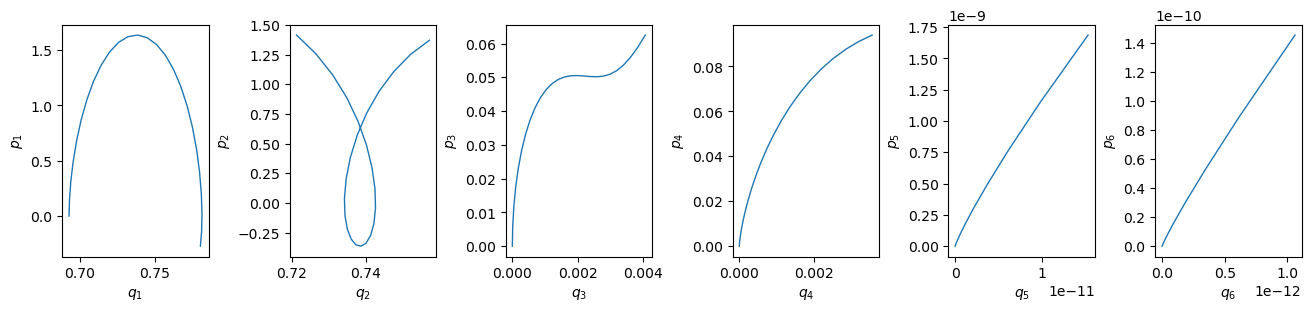

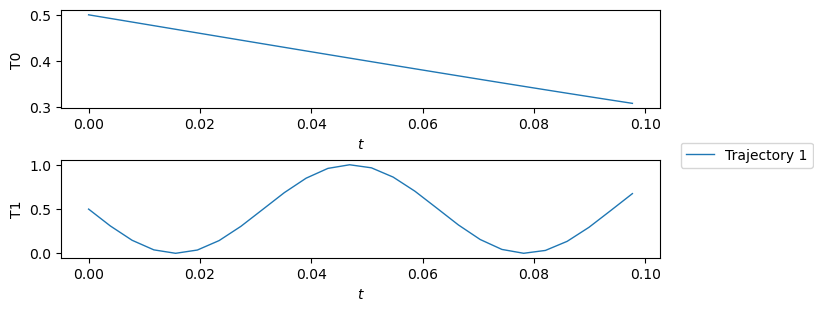

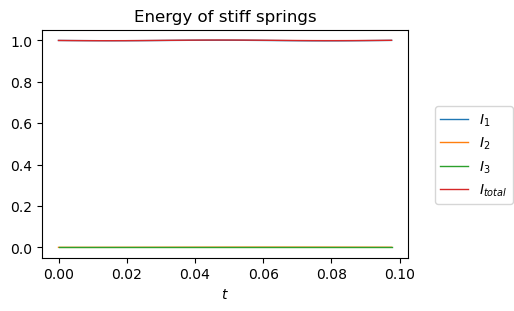

In [46]:
# O(1/omega) time

fpu = FPU(OMEGA)
func_dict = {
    # "H": fpu.compute_hamiltonian,
    "T0": fpu.compute_T0,
    "T1": fpu.compute_T1,
    # "I1": lambda u: fpu.compute_stiff_spring_energies(u)[:, 0],
    # "I2": lambda u: fpu.compute_stiff_spring_energies(u)[:, 1],
    # "I3": lambda u: fpu.compute_stiff_spring_energies(u)[:, 2],
}

traj = ref_traj.select_between(0,0.1)
print(traj)
plot_phase_space([traj])
plot_history([traj], func_dict)
plot_stiff_spring_energies_profile(traj)

FPUTrajectory(t_range=[0.0, 3.0], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(769, 12)))


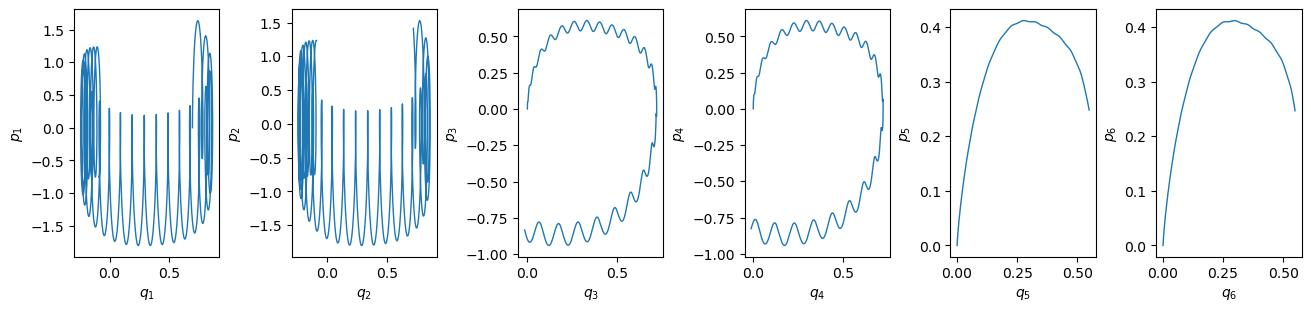

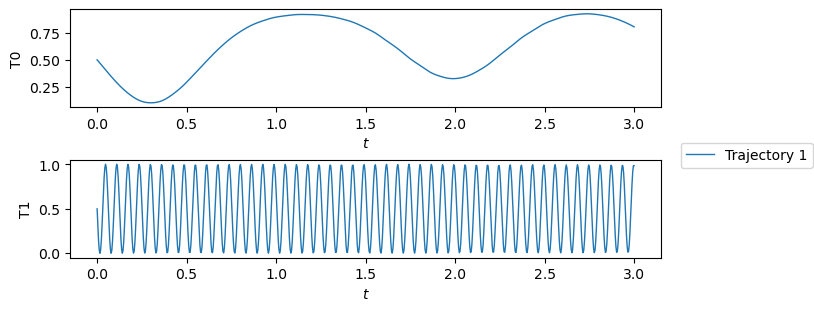

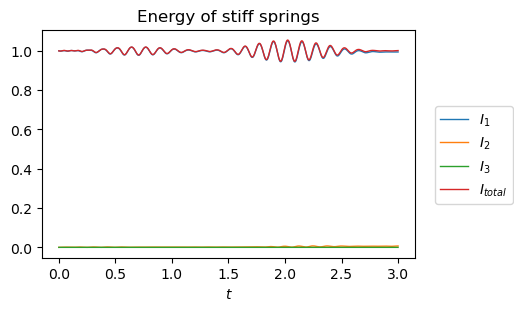

In [47]:
# O(1) time

fpu = FPU(OMEGA)
func_dict = {
    # "H": fpu.compute_hamiltonian,
    "T0": fpu.compute_T0,
    "T1": fpu.compute_T1,
    # "I1": lambda u: fpu.compute_stiff_spring_energies(u)[:, 0],
    # "I2": lambda u: fpu.compute_stiff_spring_energies(u)[:, 1],
    # "I3": lambda u: fpu.compute_stiff_spring_energies(u)[:, 2],
}

traj = ref_traj.select_between(0,3)
print(traj)
plot_phase_space([traj])
plot_history([traj], func_dict)
plot_stiff_spring_energies_profile(traj)

FPUTrajectory(t_range=[0.0, 500.0], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(128001, 12)))


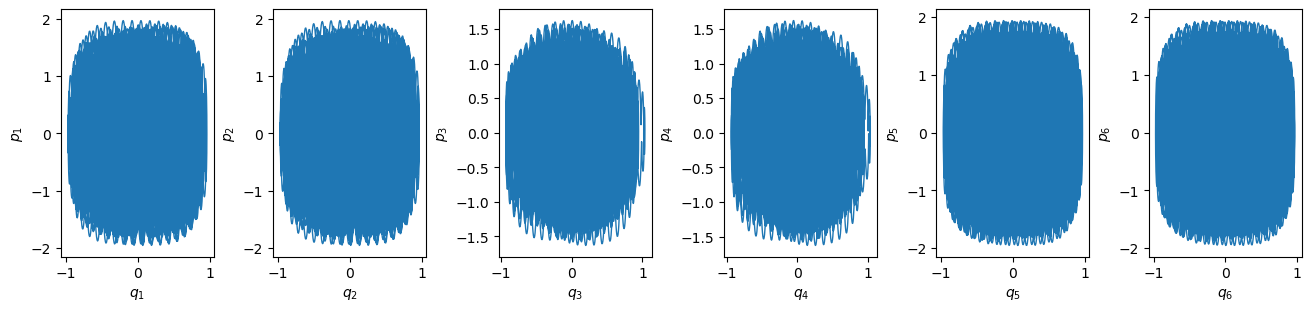

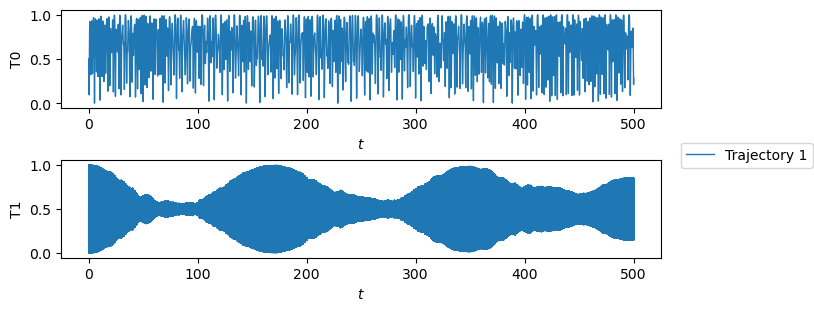

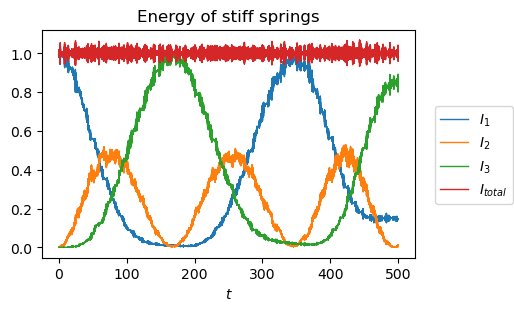

In [49]:
# O(omega) time

fpu = FPU(OMEGA)
func_dict = {
    # "H": fpu.compute_hamiltonian,
    "T0": fpu.compute_T0,
    "T1": fpu.compute_T1,
    # "I1": lambda u: fpu.compute_stiff_spring_energies(u)[:, 0],
    # "I2": lambda u: fpu.compute_stiff_spring_energies(u)[:, 1],
    # "I3": lambda u: fpu.compute_stiff_spring_energies(u)[:, 2],
    # "I_total": lambda u: fpu.compute_stiff_spring_energies(u)[:, 3],
}

traj = ref_traj.select_between(0,500)
print(traj)
plot_phase_space([traj])
plot_history([traj], func_dict)
plot_stiff_spring_energies_profile(traj)

## Inspect model checkpoints

In [4]:
import sys
sys.path.append("../deep_learning/src")

import torch

from utils.checkpoint_utils import load_model_from_ckpt
from modules.variable_timestep import T0CenteredSolutionMap
from datamodules.datasets import get_sequence_data

In [5]:
def dPhidt(model):
    return lambda u, t: torch.func.vmap(torch.func.jacrev(model, argnums=1))(u, t).squeeze(-1)  # (bs, 2*dof)

In [6]:
import re 

def get_epoch_from_ckpt(ckpt_path):
    # Search for pattern 'epoch' followed by digits
    match = re.search(r'epoch(\d+)', ckpt_path)
    if match:
        return int(match.group(1))
    return None

def load_checkpoint_history(ckpt_dir, model_name):
    ckpt_paths = glob.glob(ckpt_dir + "/*epoch*.ckpt")
    ckpt_paths = sorted(ckpt_paths, key=lambda ckpt: get_epoch_from_ckpt(ckpt))

    model_ckpts = {}
    for path in ckpt_paths:
        model_ckpts[f"epoch{get_epoch_from_ckpt(path)}"] = {
            "model_name": model_name,
            "ckpt_path": path
        }
    return model_ckpts

def find_latest_ckpt(ckpt_dir):
    latest_ckpt = glob.glob(f"{ckpt_dir}/latest*.ckpt")
    if latest_ckpt:
        return latest_ckpt[0]
    else:
        raise FileNotFoundError(f"No latest checkpoint found in {ckpt_dir}")
    
def get_batch(batch_size, data_dir, t_range=None, t=None):
    data_config = {
        "data_dir": data_dir,
        "sequence_len": 2, 
        "dtype": "float64",
        "downsample_factor": 1,
        "Dt_range": t_range,
        "Dt": t
    }
    ds = get_sequence_data(data_config)
    return ds[:batch_size]

In [7]:
def plot_deriv_error_statistics_vs_t(model_ckpts, batch, bins=41, t_range=None, ylim=None, log_yscale=True, 
                                        legend_labels=None, figsize=(8, 6), plot_fit=False):
    """Plot statistical measures of error over binned time intervals for multiple models."""
    
    if legend_labels is None:
        legend_labels = list(model_ckpts.keys()) 

    fig, ax = plt.subplots(figsize=figsize)
    
    # Loop through each group
    for ckpt_info, label in zip(model_ckpts.values(), legend_labels):
        if ckpt_info["model_name"] == "FixedStepSolutionMap":
            print(f"Skipping {label} because it is a FixedStepSolutionMap")
            continue 
        
        model, _ = load_model_from_ckpt(ckpt_info["ckpt_path"], ckpt_info["model_name"])

        u0 = batch["input"].to(model.dtype).to(model.device)
        u1 = batch["target_seq"][1].to(model.dtype).to(model.device)
        t = batch["Dt"].to(model.dtype).to(model.device)

        true_deriv = model.problem.compute_du(u1)
        pred_deriv = dPhidt(model)(u0, t)

        # true_deriv = model.problem.nondim_du(true_deriv)
        # pred_deriv = model.problem.nondim_du(pred_deriv)

        errors = torch.nn.functional.mse_loss(true_deriv, pred_deriv, reduction="none").sum(-1).sqrt()
        errors = errors.detach().cpu().numpy()
        t = t.detach().cpu().numpy().squeeze()
        # print(errors[:10])
        
        tmin, tmax = t_range if t_range is not None else (min(t), max(t))
        if isinstance(bins, int):
            bins = np.linspace(tmin, tmax, bins + 1)

        bin_indices = np.digitize(t, bins) - 1
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        min_errors = np.zeros(len(bin_centers))
        max_errors = np.zeros(len(bin_centers))
        mean_errors = np.zeros(len(bin_centers))
        std_errors = np.zeros(len(bin_centers))

        for i in range(len(bin_centers)):
            bin_errors = errors[bin_indices == i]
            if bin_errors.size > 0:
                min_errors[i] = bin_errors.min()
                max_errors[i] = bin_errors.max()
                mean_errors[i] = bin_errors.mean()
                std_errors[i] = bin_errors.std()
            else:
                min_errors[i] = max_errors[i] = mean_errors[i] = std_errors[i] = np.nan
        
        # Plot for the current group
        markers, caps, bars = ax.errorbar(bin_centers, mean_errors, yerr=std_errors, fmt='^',
                    elinewidth=2, capsize=2, label=label)
        [bar.set_alpha(0.5) for bar in bars]
        marker_color = markers.get_color() 

        if plot_fit:
            # Fit and plot the exponential curve
            x_data = t[(tmin <= t) & (t <= tmax)]
            y_data = errors[(tmin <= t) & (t <= tmax)]
            params, _ = exponential_fit(x_data, y_data)
            x_fine = np.linspace(tmin, tmax, 100)
            y_fitted = exp_func(x_fine, *params)
            ax.plot(x_fine, y_fitted, color=marker_color, linestyle='--', 
                    label=f'{label} Exp Fit: $error = {params[0]:.2f} e^{{ {params[1]:.2f} t}}$')
        
    if log_yscale:
        ax.set_yscale('log')
    ax.set_xlim(tmin, tmax)
    if ylim is not None:
        ax.set_ylim(ylim)
    # ax.set_xscale('log')
    ax.set_xlabel('$t$')
    ax.set_ylabel('$|d\Phi/dt - d\phi/dt|$')
    ax.set_title('Error Statistics vs t')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.show()


def plot_fitting_error_statistics_vs_t(model_ckpts, batch, error_name="abs_traj_err", 
                                       bins=41, t_range=None, ylim=None, log_yscale=True, 
                                        legend_labels=None, figsize=(8, 6), plot_fit=False):
    """Plot statistical measures of error over binned time intervals for multiple models."""
    
    if legend_labels is None:
        legend_labels = list(model_ckpts.keys()) 

    fig, ax = plt.subplots(figsize=figsize)
    
    # Loop through each group
    for ckpt_info, label in zip(model_ckpts.values(), legend_labels):

        model, _ = load_model_from_ckpt(ckpt_info["ckpt_path"], ckpt_info["model_name"])

        u0 = batch["input"].to(model.dtype).to(model.device)
        u1 = batch["target_seq"][1].to(model.dtype).to(model.device)
        t = batch["Dt"].to(model.dtype).to(model.device)

        true = u1
        if ckpt_info["model_name"] == "FixedStepSolutionMap":
            pred = model(u0, None, 2)[1]
        else:
            pred = model(u0, t)

        errors = model.problem.compute_errors(true, pred, reduction="none")[error_name]
        errors = errors.detach().cpu().numpy()
        t = t.detach().cpu().numpy().squeeze()
        
        tmin, tmax = t_range if t_range is not None else (min(t), max(t))
        if isinstance(bins, int):
            bins = np.linspace(tmin, tmax, bins + 1)

        bin_indices = np.digitize(t, bins) - 1
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        min_errors = np.zeros(len(bin_centers))
        max_errors = np.zeros(len(bin_centers))
        mean_errors = np.zeros(len(bin_centers))
        std_errors = np.zeros(len(bin_centers))

        for i in range(len(bin_centers)):
            bin_errors = errors[bin_indices == i]
            if bin_errors.size > 0:
                min_errors[i] = bin_errors.min()
                max_errors[i] = bin_errors.max()
                mean_errors[i] = bin_errors.mean()
                std_errors[i] = bin_errors.std()
            else:
                min_errors[i] = max_errors[i] = mean_errors[i] = std_errors[i] = np.nan
        
        # Plot for the current group
        markers, caps, bars = ax.errorbar(bin_centers, mean_errors, yerr=std_errors, fmt='^',
                    elinewidth=2, capsize=2, label=label)
        [bar.set_alpha(0.5) for bar in bars]
        marker_color = markers.get_color() 

        if plot_fit:
            # Fit and plot the exponential curve
            x_data = t[(tmin <= t) & (t <= tmax)]
            y_data = errors[(tmin <= t) & (t <= tmax)]
            params, _ = exponential_fit(x_data, y_data)
            x_fine = np.linspace(tmin, tmax, 100)
            y_fitted = exp_func(x_fine, *params)
            ax.plot(x_fine, y_fitted, color=marker_color, linestyle='--', 
                    label=f'{label} Exp Fit: $error = {params[0]:.2f} e^{{ {params[1]:.2f} t}}$')
        
    if log_yscale:
        ax.set_yscale('log')
    ax.set_xlim(tmin, tmax)
    if ylim is not None:
        ax.set_ylim(ylim)
    # ax.set_xscale('log')
    ax.set_xlabel('$t$')
    ax.set_ylabel(error_name)
    ax.set_title('Error Statistics vs t')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.show()


def plot_numerical_residual_error_statistics_vs_t(model_ckpts, batch, 
                               vv_config=None, bins=41, t_range=None, ylim=None, log_yscale=True, 
                               legend_labels=None, figsize=(8, 6), plot_fit=False):
    """Plot statistical measures of error over binned time intervals for multiple models."""
    
    
    if vv_config is None: 
        vv_config = {"method": "VelocityVerlet", "stepsize": 1e-3, "nsteps": 1}

    if legend_labels is None:
        legend_labels = list(model_ckpts.keys()) 

    fig, ax = plt.subplots(figsize=figsize)
    
    # Loop through each group
    for ckpt_info, label in zip(model_ckpts.values(), legend_labels):
        if ckpt_info["model_name"] == "FixedStepSolutionMap":
            print(f"Skipping {label} because it is a FixedStepSolutionMap")
            continue

        model, _ = load_model_from_ckpt(ckpt_info["ckpt_path"], ckpt_info["model_name"])

        vv = model._instantiate_integrator(vv_config)

        u0 = batch["input"].to(model.dtype).to(model.device)
        # t = batch["Dt"].to(model.dtype).to(model.device)
        t = model._prepare_random_timesteps(len(u0), {"type": "uniform", "min": t_range[0], "max": t_range[1]})

        errors = model._calc_numerical_residual_error(u0, t, vv, reduction="none").sum(dim=-1).sqrt()  # (bs,)
        errors = errors.detach().cpu().numpy()
        t = t.detach().cpu().numpy().squeeze()
        
        tmin, tmax = t_range if t_range is not None else (min(t), max(t))
        if isinstance(bins, int):
            bins = np.linspace(tmin, tmax, bins + 1)

        bin_indices = np.digitize(t, bins) - 1
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        min_errors = np.zeros(len(bin_centers))
        max_errors = np.zeros(len(bin_centers))
        mean_errors = np.zeros(len(bin_centers))
        std_errors = np.zeros(len(bin_centers))

        for i in range(len(bin_centers)):
            bin_errors = errors[bin_indices == i]
            if bin_errors.size > 0:
                min_errors[i] = bin_errors.min()
                max_errors[i] = bin_errors.max()
                mean_errors[i] = bin_errors.mean()
                std_errors[i] = bin_errors.std()
            else:
                min_errors[i] = max_errors[i] = mean_errors[i] = std_errors[i] = np.nan
        
        # Plot for the current group
        markers, caps, bars = ax.errorbar(bin_centers, mean_errors, yerr=std_errors, fmt='^',
                    elinewidth=2, capsize=2, label=label)
        [bar.set_alpha(0.5) for bar in bars]
        marker_color = markers.get_color() 

        if plot_fit:
            # Fit and plot the exponential curve
            x_data = t[(tmin <= t) & (t <= tmax)]
            y_data = errors[(tmin <= t) & (t <= tmax)]
            params, _ = exponential_fit(x_data, y_data)
            x_fine = np.linspace(tmin, tmax, 100)
            y_fitted = exp_func(x_fine, *params)
            ax.plot(x_fine, y_fitted, color=marker_color, linestyle='--', 
                    label=f'{label} Exp Fit: $error = {params[0]:.2f} e^{{ {params[1]:.2f} t}}$')
        
    if log_yscale:
        ax.set_yscale('log')
    ax.set_xlim(tmin, tmax)
    if ylim is not None:
        ax.set_ylim(ylim)
    # ax.set_xscale('log')
    ax.set_xlabel('$t$')
    ax.set_ylabel('$|VV_h(\Phi(t)) - \Phi(t+h)|$')
    ax.set_title('Error Statistics vs t')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.show()


def plot_residual_error_statistics_vs_t(model_ckpts, batch,
                                    bins=41, t_range=None, ylim=None, log_yscale=True, 
                               legend_labels=None, figsize=(8, 6), plot_fit=False):
    """Plot statistical measures of error over binned time intervals for multiple models."""

    if legend_labels is None:
        legend_labels = list(model_ckpts.keys()) 

    fig, ax = plt.subplots(figsize=figsize)
    
    # Loop through each group
    for ckpt_info, label in zip(model_ckpts.values(), legend_labels):
        if ckpt_info["model_name"] == "FixedStepSolutionMap":
            print(f"Skipping {label} because it is a FixedStepSolutionMap")
            continue 

        model, _ = load_model_from_ckpt(ckpt_info["ckpt_path"], ckpt_info["model_name"])

        u0 = batch["input"].to(model.dtype).to(model.device)
        # t = batch["Dt"].to(model.dtype).to(model.device)
        t = model._prepare_random_timesteps(len(u0), {"type": "uniform", "min": t_range[0], "max": t_range[1]})


        errors = model._calc_residual_error(u0, t, reduction="none").sum(dim=-1).sqrt()  # (bs,)
        errors = errors.detach().cpu().numpy()
        t = t.detach().cpu().numpy().squeeze()
        
        tmin, tmax = t_range if t_range is not None else (min(t), max(t))
        if isinstance(bins, int):
            bins = np.linspace(tmin, tmax, bins + 1)

        bin_indices = np.digitize(t, bins) - 1
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        min_errors = np.zeros(len(bin_centers))
        max_errors = np.zeros(len(bin_centers))
        mean_errors = np.zeros(len(bin_centers))
        std_errors = np.zeros(len(bin_centers))

        for i in range(len(bin_centers)):
            bin_errors = errors[bin_indices == i]
            if bin_errors.size > 0:
                min_errors[i] = bin_errors.min()
                max_errors[i] = bin_errors.max()
                mean_errors[i] = bin_errors.mean()
                std_errors[i] = bin_errors.std()
            else:
                min_errors[i] = max_errors[i] = mean_errors[i] = std_errors[i] = np.nan
        
        # Plot for the current group
        markers, caps, bars = ax.errorbar(bin_centers, mean_errors, yerr=std_errors, fmt='^',
                    elinewidth=2, capsize=2, label=label)
        [bar.set_alpha(0.5) for bar in bars]
        marker_color = markers.get_color() 

        if plot_fit:
            # Fit and plot the exponential curve
            x_data = t[(tmin <= t) & (t <= tmax)]
            y_data = errors[(tmin <= t) & (t <= tmax)]
            params, _ = exponential_fit(x_data, y_data)
            x_fine = np.linspace(tmin, tmax, 100)
            y_fitted = exp_func(x_fine, *params)
            ax.plot(x_fine, y_fitted, color=marker_color, linestyle='--', 
                    label=f'{label} Exp Fit: $error = {params[0]:.2f} e^{{ {params[1]:.2f} t}}$')
        
    if log_yscale:
        ax.set_yscale('log')
    ax.set_xlim(tmin, tmax)
    if ylim is not None:
        ax.set_ylim(ylim)
    # ax.set_xscale('log')
    ax.set_xlabel('$t$')
    ax.set_ylabel('$|d\Phi(t)/dt - F(\Phi(t))|$')
    ax.set_title('Error Statistics vs t')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.show()

In [8]:
# Load latest checkpoint in given directories

model_ckpts = {
    "T0-centered: Data at t=0.125 + VV normal(0.125,0.05)": {
        "model_name": "T0CenteredSolutionMap",
        "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241008-032422_wxwmuh/checkpoints",
    },
    "IdentityEnforced: VV normal(0.125,0.05)": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241008-142444_mhlw6y/checkpoints",
    },
    "FixedStep: Data at t=0.125": {
        "model_name": "FixedStepSolutionMap",
        "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241008-020031_j3zwwt/checkpoints",
    },
}

for label in model_ckpts.keys():
    model_ckpts[label]["ckpt_path"] = find_latest_ckpt(model_ckpts[label]["ckpt_dir"])

for key, val in model_ckpts.items():
    print(key, val)

T0-centered: Data at t=0.125 + VV normal(0.125,0.05) {'model_name': 'T0CenteredSolutionMap', 'ckpt_dir': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241008-032422_wxwmuh/checkpoints', 'ckpt_path': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241008-032422_wxwmuh/checkpoints/latest-epoch00312.ckpt'}
IdentityEnforced: VV normal(0.125,0.05) {'model_name': 'IdentityEnforcedSolutionMap', 'ckpt_dir': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241008-142444_mhlw6y/checkpoints', 'ckpt_path': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241008-142444_mhlw6y/checkpoints/latest-epoch00312.ckpt'}
FixedStep: Data at t=0.125 {'model_name': 'FixedStepSolutionMap', 'ckpt_dir': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241008-020031_j3zwwt/checkpoints', 'ckpt_path': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241008-020031_j3zwwt/checkpoints/latest

Skipping FixedStep: Data at t=0.125 because it is a FixedStepSolutionMap


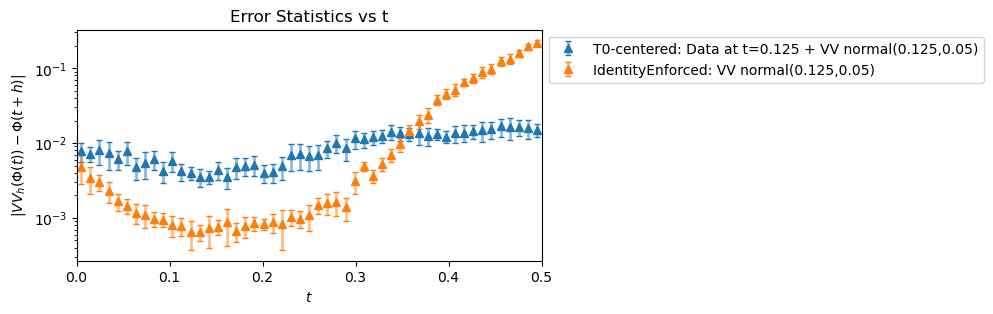

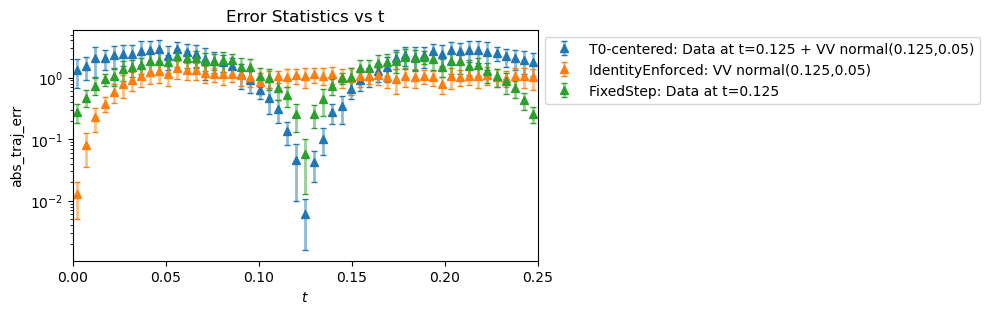

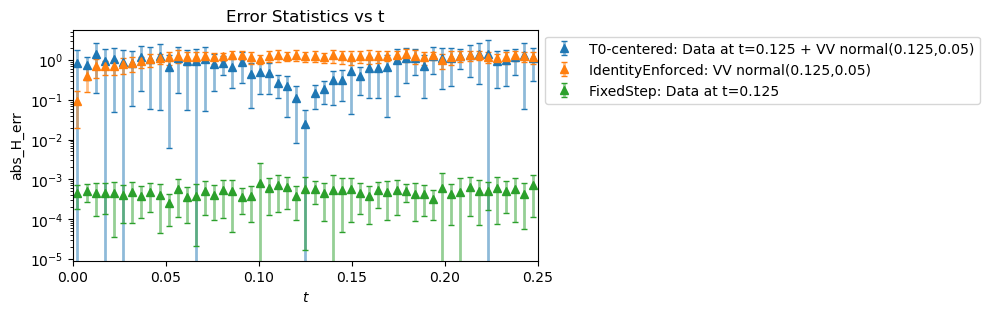

In [9]:
t_range = (0, 0.25)

batch = get_batch(
    batch_size=1000, 
    data_dir="/workspace/projects_rui/learnsolnmap/data1/fpu/omega=50/version1/max_Dt=2.5e-1_min_Dt=-2.5e-1/test",
    t_range=t_range
)

plot_numerical_residual_error_statistics_vs_t(
    model_ckpts,
    batch=batch,
    t_range=(0, 0.5),
    bins=51,
    figsize=(6, 3),
    # ylim=(1e-4, 1e0),
)

# plot_residual_error_statistics_vs_t(
#     model_ckpts,
#     batch=batch,
#     t_range=t_range,
#     bins=51,
#     figsize=(6, 3),
#     ylim=(1e-3, 1e2),
# )

# plot_deriv_error_statistics_vs_t(
#     model_ckpts, 
#     batch=batch,
#     t_range=t_range,
#     bins=51,
#     figsize=(6, 3),
#     ylim=(1e-2, 1e2),
# )

for error_name in ["abs_traj_err", "abs_H_err"]:
    plot_fitting_error_statistics_vs_t(
        model_ckpts, 
        error_name=error_name,
        batch=batch,
        t_range=t_range,
        bins=51,
        figsize=(6, 3),
        # ylim=(1e-3, 5e1),
    )


### Evaluate determinants of Jacobian 

In [5]:
import sys
import torch
from torch.func import jacrev

# setting path
sys.path.append('../deep_learning/src')
 
from utils.checkpoint_utils import load_model_from_ckpt

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:1")
print("Using device", device)

def compute_jacobian_autodiff(x, solnmap):
    # x shape: (bs, n_in)
    jac = jacrev(lambda x: solnmap.forward_1step(x))(x)  # (bs, n_out, bs, n_in)
    jac = torch.diagonal(jac, dim1=0, dim2=2)  # (n_out, n_in, bs)
    jac = torch.permute(jac, (2, 0, 1))  # (bs, n_out, n_in)
    return jac

def compute_determinant(x, solnmap):
    # x shape: (bs, n_in)
    jac = compute_jacobian_autodiff(x, solnmap)
    det = torch.det(jac)
    return det

def batch_process(x, batch_size, process_fn):
    dataloader = torch.utils.data.DataLoader(x, batch_size=batch_size, shuffle=False)
    results = []
    for x_batch in dataloader:
        results.append(process_fn(x_batch))
    return torch.cat(results, dim=0)

Using device cuda:1


In [6]:
test_inputs_path = "/workspace/projects_rui/learnsolnmap/data1/fpu/omega=300/version4/Dt=1e0/test/U0.csv"
test_inputs, _ = load_data(test_inputs_path)
test_inputs = torch.tensor(test_inputs, dtype=torch.float32).to(device)

(40000, 12)


In [14]:
ckpt_paths = [
    "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20240812-151354_cpk7er/checkpoints/epoch00989-val_loss2.738e-07.ckpt",  # AnchoredEnergyNormSquaredLoss
    "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20240813-214334_mp1ws2/checkpoints/epoch00459-val_loss2.715e-07.ckpt",  # MSELoss
    "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20240813-213029_6z19uj/checkpoints/epoch00469-val_loss4.214e-07.ckpt",  # VV 
]

labels = [
    "AnchoredEnergyNormSquaredLoss",
    "MSELoss",
    "VV"
]

In [7]:
ckpt_paths = [
    "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20240820-001828_pu02hz/checkpoints/epoch00499-val_loss1.195e-07.ckpt",  # EnergyBalanced Misfit
    "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20240820-002437_idu8xj/checkpoints/epoch00499-val_loss1.246e-07.ckpt",  # EnergyBalanced Integrator
]

labels = [
    "EnergyBalanced Misfit",
    "EnergyBalanced Integrator"
]

In [8]:
models = []
for ckpt_path in ckpt_paths:
    model, _ = load_model_from_ckpt(ckpt_path)
    model.to(device)
    models.append(model)

In [9]:
results = {}
for model, label in zip(models, labels):
    determinants = batch_process(test_inputs, 100, lambda x: compute_determinant(x, model).detach().cpu())
    results[label] = determinants

In [10]:
torch.cuda.empty_cache()

In [11]:
for label in labels:
    print(f"Model: {label}")
    determinants = results[label].numpy()
    print("mean = {0:.3e}, std = {1:.3e}".format(determinants.mean(), determinants.std()))

Model: EnergyBalanced Misfit
mean = 1.001e+00, std = 7.484e-03
Model: EnergyBalanced Integrator
mean = 1.001e+00, std = 7.943e-03


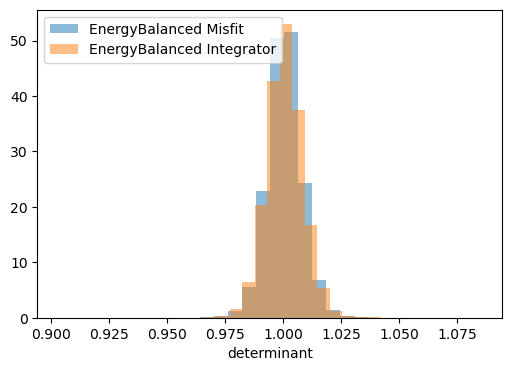

In [12]:
plt.figure(figsize=(6, 4))
for label in labels:
    determinants = results[label].numpy()
    plt.hist(determinants, bins=30, density=True, alpha=0.5, label=label)
plt.xlabel("determinant")
plt.legend()
plt.show()

In [13]:
def plot_errors_vs_location(u_true, diff, indices, cmap="viridis", title=None):
    x = u_true[indices, 6]
    y = u_true[indices, 8]
    z = u_true[indices, 10]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(x, y, z, s=1, c=diff[indices], cmap=cmap)
    plt.colorbar(scatter)
    ax.set_xlabel("q1")
    ax.set_ylabel("q3")
    ax.set_zlabel("q5")

    if title:
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

Model: EnergyBalanced Misfit


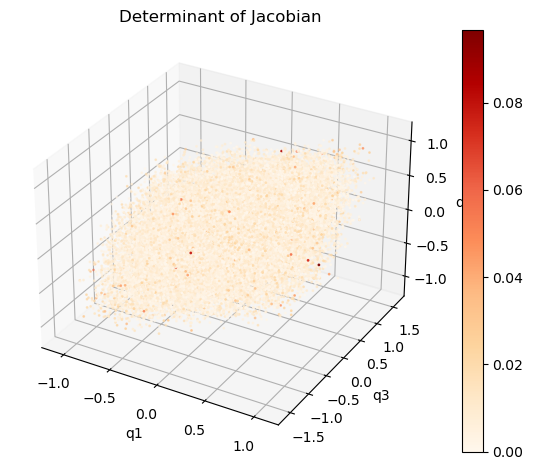

Model: EnergyBalanced Integrator


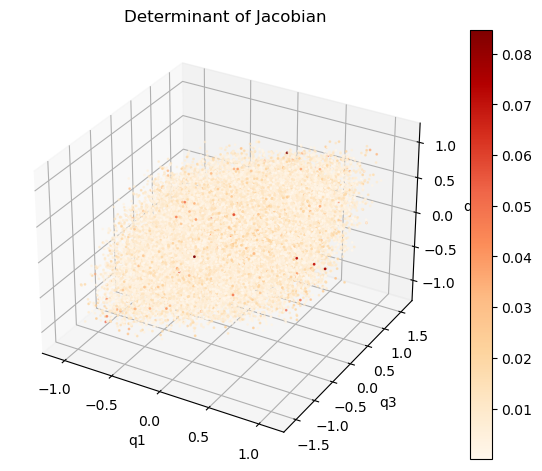

In [14]:
title = "Determinant of Jacobian"

for label in labels:
    print(f"Model: {label}")
    determinants = results[label].numpy()
    diff = np.abs(determinants - 1)
    plot_errors_vs_location(test_inputs.cpu(), diff, np.arange(len(test_inputs))[::1], title=title, cmap="OrRd")

## Compare trained models

In [15]:
model_dirs = [
    "/workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20240820-001828_pu02hz_energybalanced_misfit",
    "/workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20240820-002437_idu8xj_energybalanced_integrator",
]

model_labels = [
    "EnergyBalanced Misfit",
    "EnergyBalanced Integrator"
]


### Metrics

In [16]:
model_metrics = {}

for model_dir, label in zip(model_dirs, model_labels): 
    filepath_metrics = model_dir + "/test_metrics.csv"
    df = pd.read_csv(filepath_metrics, header=1, names=['Metric', 'Value'])
    model_metrics[label] = df.set_index('Metric')['Value']

df = pd.DataFrame(model_metrics).T

metric_names = [
    "test/traj_err_step1", 
    "test/traj_err_step2",  
    "test/traj_err_step3",
    "test/traj_err_step4",
    "test/traj_err_step5"]
df[metric_names]
print(df[metric_names].to_markdown(floatfmt='.3e'))

|                           |   test/traj_err_step1 |   test/traj_err_step2 |   test/traj_err_step3 |   test/traj_err_step4 |   test/traj_err_step5 |
|:--------------------------|----------------------:|----------------------:|----------------------:|----------------------:|----------------------:|
| EnergyBalanced Misfit     |             8.677e-04 |             1.355e-03 |             1.840e-03 |             2.328e-03 |             2.861e-03 |
| EnergyBalanced Integrator |             8.962e-04 |             1.398e-03 |             1.899e-03 |             2.400e-03 |             2.931e-03 |


In [17]:
metric_names = [
    "test/H_err_step1", 
    "test/H_err_step2",  
    "test/H_err_step3",
    "test/H_err_step4",
    "test/H_err_step5"]
df[metric_names]
print(df[metric_names].to_markdown(floatfmt='.3e'))

|                           |   test/H_err_step1 |   test/H_err_step2 |   test/H_err_step3 |   test/H_err_step4 |   test/H_err_step5 |
|:--------------------------|-------------------:|-------------------:|-------------------:|-------------------:|-------------------:|
| EnergyBalanced Misfit     |          4.999e-04 |          7.444e-04 |          9.317e-04 |          1.079e-03 |          1.202e-03 |
| EnergyBalanced Integrator |          5.206e-04 |          7.813e-04 |          9.774e-04 |          1.139e-03 |          1.277e-03 |


### Long-time trajectory 1 

In [18]:
dt = 1. 

filepath_ref = "/workspace/projects_rui/learnsolnmap/out/fpu/omega=50/202408200020/ref/k=0/u.csv"
u_ref, tt_ref = load_data(filepath_ref, dt)

model_preds = []
for model_dir in model_dirs:
    filepath_pred = model_dir + "/predictions/traj1.csv"
    u, tt = load_data(filepath_pred, dt)
    model_preds.append((tt, u))

(501, 12)
(1001, 12)
(1001, 12)


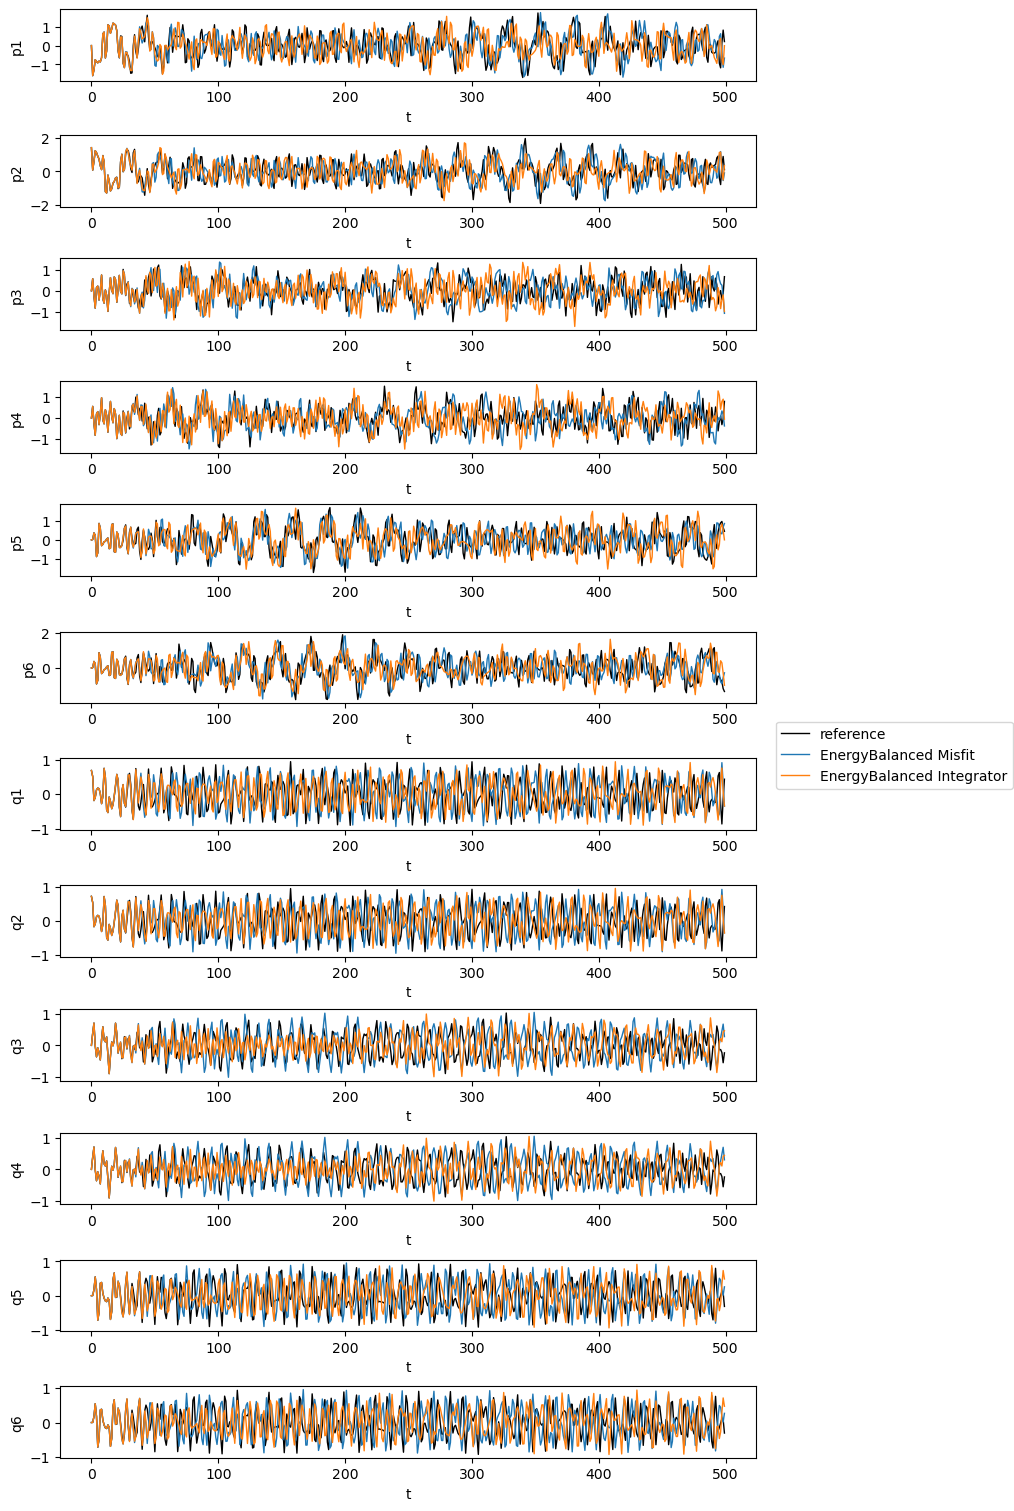

In [25]:
# Phase space variables vs time 

indices = np.arange(len(model_preds[0][0]))[:500:1]

fig, axes = plt.subplots(12, 1, figsize=(10, 15), layout='constrained')

for i, ax in enumerate(axes):
    ax.plot(tt_ref[indices], u_ref[indices, i], "k-", lw=1, label="reference")
    for (t, u), label in zip(model_preds, model_labels):
        ax.plot(t[indices], u[indices, i], "-", lw=1, label=label)
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    ax.set_xlabel("t")
    if i < 6:
        ax.set_ylabel(f"p{i+1}")
    else:
        ax.set_ylabel(f"q{i-5}")

fig.legend(handles, labels, loc='outside center right', borderaxespad=0.1)
plt.show()

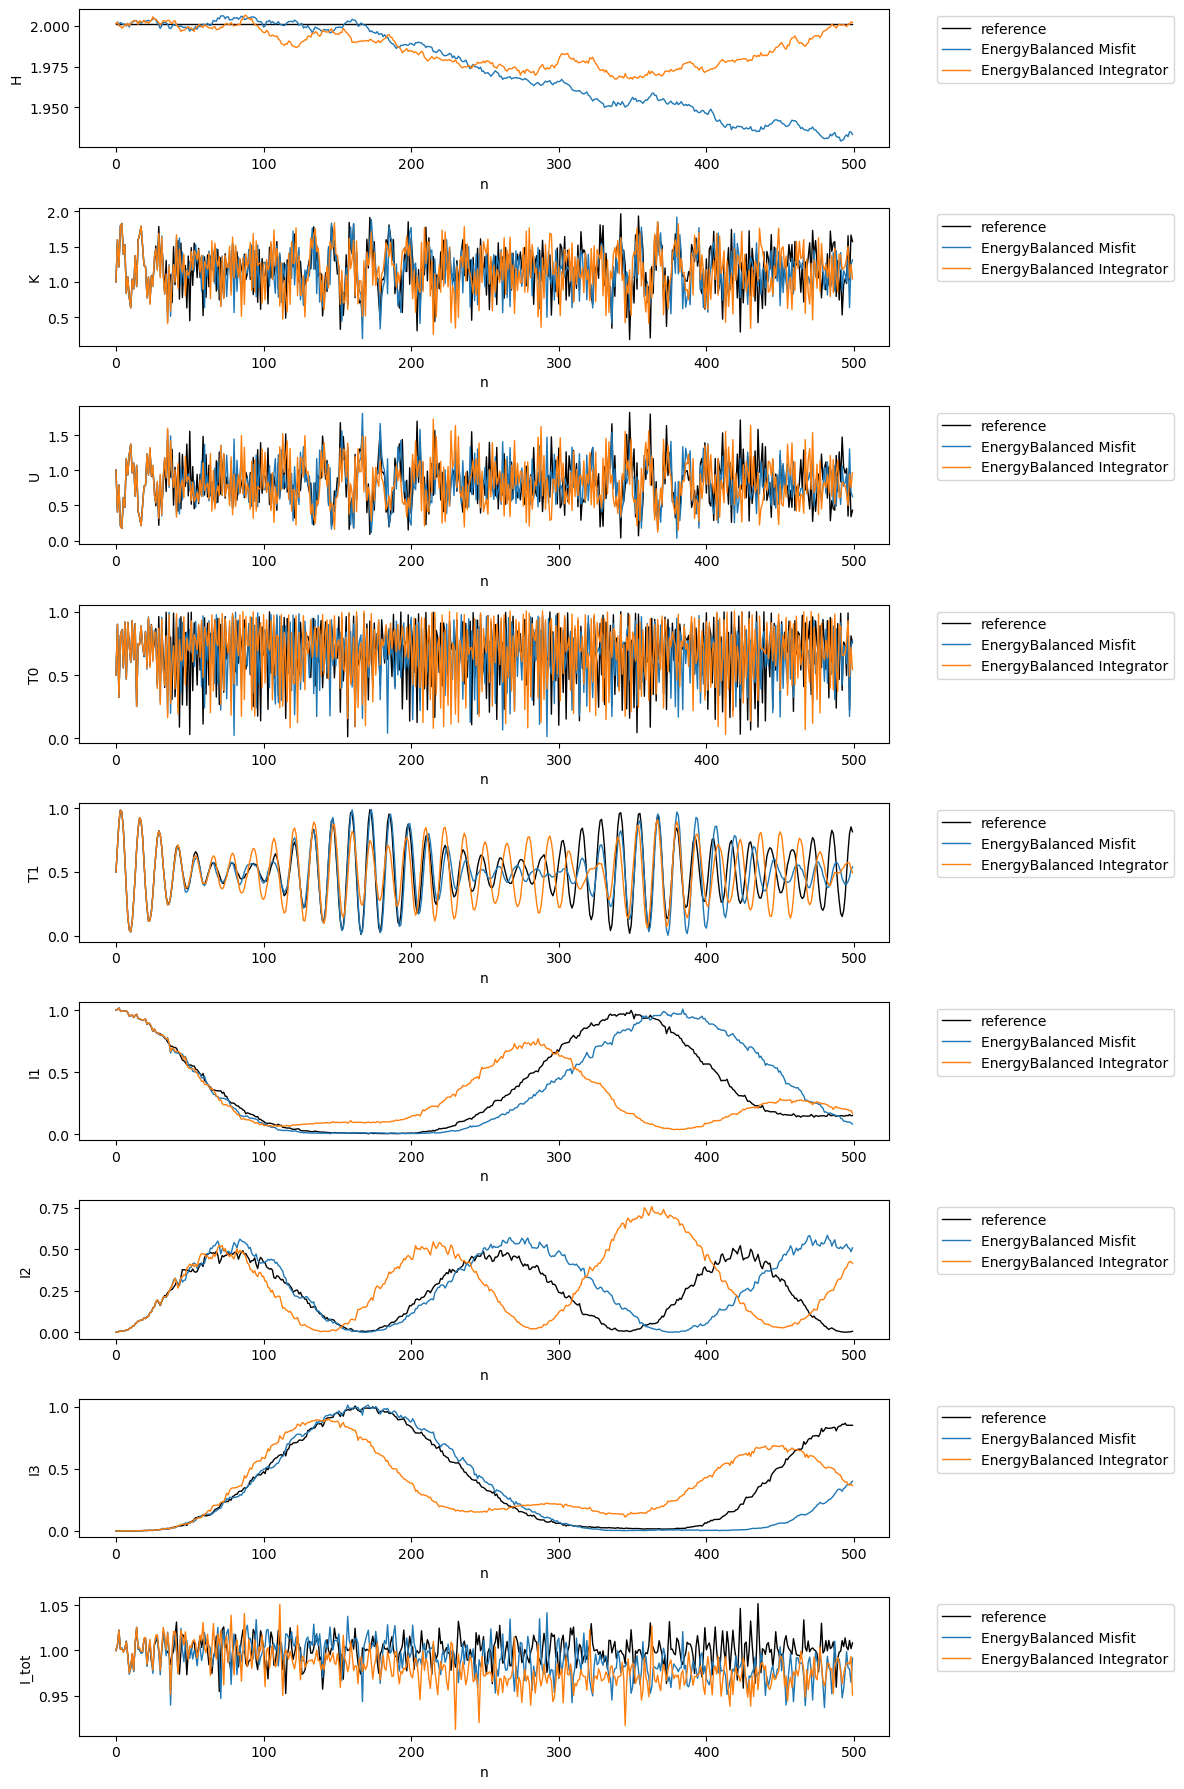

In [27]:
# Energies vs time  

energies_of_preds = [compute_energies(u, omega=50) for (t, u) in model_preds]
ref_energies = compute_energies(u_ref, omega=50)

indices = np.arange(len(model_preds[0][0]))[:500:1]
ref_indices = indices*1

keys = list(energies_of_preds[0].keys())
n_subplots = len(keys)

plt.figure(figsize=(12, n_subplots*2))

for i in range(n_subplots):
    plt.subplot(n_subplots, 1, i+1)
    plt.plot(tt_ref[ref_indices], ref_energies[keys[i]][ref_indices], "-", lw=1, color="k", label="reference")
    for j in range(len(model_preds)):
        plt.plot(indices, energies_of_preds[j][keys[i]][indices], "-", lw=1, label=model_labels[j])
    plt.xlabel("n")
    plt.ylabel(keys[i])
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

plt.tight_layout()
plt.show()